In [1]:
import os
os.environ['PYTORCH_ENABLE_MPS_FALLBACK'] = '1'
os.environ['PYTORCH_MPS_HIGH_WATERMARK_RATIO']= '0.0'
import argparse
import os
import shutil
import timm
import torch
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from datasets import load_cifar10, load_cifar100, load_caltech256, load_flowers, load_dogs


normalize_mean = [0.485, 0.456, 0.406]
normalize_std  = [0.229, 0.224, 0.225]

In [58]:
"""
if args.model == 'resnet50':
    model_key = 'resnet50'
elif args.model == 'vitb':
    model_key = 'vit_base_patch16_224'
elif args.model == 'swinb':
    model_key = 'swin_base_patch4_window7_224'
else:
    raise Exception("Model key not added")
"""
from collections import OrderedDict
model_key='resnet50'
pretrained_model = timm.create_model(model_key, pretrained=False, num_classes=10)
original_state_dict = torch.load('models/resnet50_cifar10_eps8_fgsm_scratch.pt', map_location=torch.device('cpu'))
new_state_dict = OrderedDict()

for key, value in original_state_dict.items():
    if key.startswith('2.'):
        new_key = key[2:]
        new_state_dict[new_key] = value
    else:
        new_state_dict[key] = value

pretrained_model.load_state_dict(new_state_dict)

# Reshape the linear head to fit the number of classes
if hasattr(pretrained_model, 'fc'):
    pretrained_model.fc = torch.nn.Linear(pretrained_model.fc.in_features, num_classes)
elif hasattr(pretrained_model, 'head'):
    pretrained_model.head = torch.nn.Linear(pretrained_model.head.in_features, num_classes)
else:
    raise Exception("FC layer name error")

# Reshape input of dataset to 224x224 from within the model (to make adversarial epsilon standard)
pre_model_seq = torch.nn.Sequential(
    torchvision.transforms.Resize((224,224)),
    torchvision.transforms.Normalize(normalize_mean, normalize_std),
    pretrained_model
)
device = torch.device('mps')
pre_model_seq.to(device)

Sequential(
  (0): Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
  (1): Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
  (2): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act1): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act1): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act2): ReLU(inplace=True)
        (conv3): Conv2d(64, 25

In [49]:
import torch.nn as nn
import torch.nn.functional as F
%env PYTORCH_ENABLE_MPS_FALLBACK=1

def pgd(model=None, X:torch.Tensor=None, Y:torch.Tensor=None, eps:float=8./255, 
        num_steps:int=10, step_size:float=2./255, targeted:bool=False, device=torch.device('mps'), use_delta=False, gradalign=False)->torch.Tensor:
    """
    this pgd assumes the data passed to it is in the range of [0,1]
    """
    loss = nn.CrossEntropyLoss()
    
    delta = torch.zeros_like(X).to(device)

    if use_delta:
        delta = delta.uniform_(-eps, eps)
    
    X_pgd = (X.clone().detach() + delta).requires_grad_(True)

    # optimzation: disable parameter grad computation
    requires_grad_list = []
    for p in model.parameters(): 
        requires_grad_list.append(p.requires_grad)
        p.requires_grad_(False)
    
    # check if model was in eval mode
    was_eval = not model.training

    if targeted: step_size *= -1
    if model.training: model.eval()
    for _ in range(num_steps):
        X_pgd.grad = None
        #print(Y.size(), model(X_pgd).size())
        out = loss(model(X_pgd), Y)
        out.backward()
        if gradalign:
            grad1 = X_pgd.grad.detach().clone()
            delt = torch.zeros_like(X).to(device)
            delt = delt.uniform_(-eps, eps)
            X2 = (X.clone().detach() + delt).requires_grad_(True)
            grad2 = return_grad(model, X2, Y, eps, device)
        with torch.no_grad():
            X_tmp = X_pgd + step_size*X_pgd.grad.sign()
            scaled_diff = torch.clamp(X_tmp - X, -eps, eps)
            X_pgd.data = torch.clamp(X.data + scaled_diff, 0, 1)
  
    # reset the model grad and requires_grad_ state
    for p, b in zip(model.parameters(), requires_grad_list): 
        p.grad = None
        p.requires_grad_(b)

    # reset model state
    if not was_eval: 
        model.train()

    if not gradalign:
        return X_pgd.detach()
    else:
        fgrad1 = torch.flatten(grad1, start_dim=1)
        fgrad2 = torch.flatten(grad2, start_dim=1)
        return X_pgd.detach(), F.cosine_similarity(fgrad1, fgrad2).mean()
        

def return_grad(model=None, X:torch.Tensor=None, Y:torch.Tensor=None, eps:float=8./255, device=torch.device('mps')):

    loss = nn.CrossEntropyLoss()
    X_clone = X.clone().detach().requires_grad_(True)

    X_clone.grad = None
    out = loss(model(X_clone), Y)
    out.backward()
    with torch.no_grad():
        X_grad = X_clone.grad.detach().clone()

    return X_grad

env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [5]:
#run mutiple steps and then get the final direction of the sum of each step. I then use this as the adversarial direction
#do this by getting the adversarial perturbed image and then subtracting the original image from it

In [59]:
_, _, trainloader, testloader, num_classes = load_cifar10(train_batch_size=128, test_batch_size=10)
image, label = next(iter(testloader))

Number of classes: 10


In [61]:

device = torch.device('mps')
pre_model_seq.to(device)
X = image.to(device)
Y = label.to(device)
X_adv = torch.clamp(pgd(pre_model_seq, X, Y, eps=8./255), 0.0, 1.0).requires_grad_(False)

In [62]:
print(torch.argmax(pre_model_seq(X), dim=1))
print(Y)
print(torch.argmax(pre_model_seq(X[7].unsqueeze(0))))
print(Y[7])

tensor([0, 1, 0, 8, 5, 0, 1, 0, 0, 0], device='mps:0')
tensor([3, 8, 8, 0, 6, 6, 1, 6, 3, 1], device='mps:0')
tensor(0, device='mps:0')
tensor(6, device='mps:0')


In [21]:
direction = X_adv[0] - X[0]

In [22]:
direction[0]

tensor([[ 1.5686e-02,  0.0000e+00,  0.0000e+00,  ...,  3.1373e-02,
          2.9802e-08, -2.3529e-02],
        [-1.5686e-02,  1.5686e-02, -3.1373e-02,  ..., -1.5686e-02,
         -1.5686e-02,  1.5686e-02],
        [-1.5686e-02, -1.5686e-02,  3.1373e-02,  ..., -3.1373e-02,
         -2.3529e-02, -3.1373e-02],
        ...,
        [ 3.1373e-02,  2.3529e-02,  2.3529e-02,  ..., -3.1373e-02,
          0.0000e+00, -3.1373e-02],
        [ 3.1373e-02,  3.1373e-02,  1.5686e-02,  ...,  3.1373e-02,
          3.1373e-02,  3.1373e-02],
        [ 1.5686e-02,  1.5686e-02,  0.0000e+00,  ...,  1.5686e-02,
         -3.1373e-02,  0.0000e+00]], device='mps:0')

In [23]:
import torch.nn as nn
import torch.nn.functional as F
%env PYTORCH_ENABLE_MPS_FALLBACK=1

def FGSM(model=None, X:torch.Tensor=None, Y:torch.Tensor=None, eps:float=8./255, device=torch.device('mps'))->torch.Tensor:
    """
    this FGSM assumes the data passed to it is in the range of [0,1]
    """
    loss = nn.CrossEntropyLoss()
    
    X_adv = (X.clone().detach()).requires_grad_(True)

    # optimzation: disable parameter grad computation
    requires_grad_list = []
    for p in model.parameters(): 
        requires_grad_list.append(p.requires_grad)
        p.requires_grad_(False)
    
    # check if model was in eval mode
    was_eval = not model.training

    if model.training: model.eval()
    X_adv.grad = None
    out = loss(model(X_adv), Y)
    out.backward()
    with torch.no_grad():
        X_tmp = X_adv + eps * X_adv.grad.sign()
        X_adv.data = torch.clamp(X_tmp, 0, 1)
  
    # reset the model grad and requires_grad_ state
    for p, b in zip(model.parameters(), requires_grad_list):  
        p.grad = None
        p.requires_grad_(b)

    if not was_eval:  
        model.train()

    return X_adv.detach()
        


env: PYTORCH_ENABLE_MPS_FALLBACK=1


In [24]:
pgd_dir = direction[0]
X_adv = torch.clamp(FGSM(pre_model_seq, X, Y, eps=8./255), 0.0, 1.0).requires_grad_(False)
direction2 = X_adv[0] - X[0]
fgsm_dir = direction2[0]

In [25]:
def loss_landscape(model, X, Y, pgd_dir, fgsm_dir, num_steps=32):
    num_steps += 1
    requires_grad_list = []
    for p in model.parameters(): 
        requires_grad_list.append(p.requires_grad)
        p.requires_grad_(False)
    loss = nn.CrossEntropyLoss()
    x_coord = np.outer(np.arange(0, num_steps, 1), np.ones(num_steps))
    y_coord = x_coord.T
    z_coord = np.array([np.zeros(num_steps) for i in range(num_steps)])
    model.eval()
    #rand_dir = torch.randn_like(direction)
    #rand_dir = rand_dir * torch.norm(direction) / torch.norm(rand_dir)
    # direction = direction / torch.norm(direction)
    #rand_dir -= direction * torch.sum(direction * rand_dir)
    #rand_dir = rand_dir / torch.norm(rand_dir)
    print(direction)
    with torch.no_grad():
        for xstep in range(num_steps):
            for ystep in range(num_steps):
                newX = X + xstep * pgd_dir + ystep * fgsm_dir
                newX = torch.clamp(newX, 0, 1)
                adv_loss = loss(model(newX), Y)
                z_coord[xstep][ystep] = adv_loss.item()

    for p, b in zip(model.parameters(), requires_grad_list): 
        p.grad = None
        p.requires_grad_(b)

    X.requires_grad_(False)

    return x_coord, y_coord, z_coord
    

In [26]:
x, y, z = loss_landscape(pre_model_seq, X[0].unsqueeze(0), Y[0].unsqueeze(0), pgd_dir, fgsm_dir)

tensor([[[ 1.5686e-02,  0.0000e+00,  0.0000e+00,  ...,  3.1373e-02,
           2.9802e-08, -2.3529e-02],
         [-1.5686e-02,  1.5686e-02, -3.1373e-02,  ..., -1.5686e-02,
          -1.5686e-02,  1.5686e-02],
         [-1.5686e-02, -1.5686e-02,  3.1373e-02,  ..., -3.1373e-02,
          -2.3529e-02, -3.1373e-02],
         ...,
         [ 3.1373e-02,  2.3529e-02,  2.3529e-02,  ..., -3.1373e-02,
           0.0000e+00, -3.1373e-02],
         [ 3.1373e-02,  3.1373e-02,  1.5686e-02,  ...,  3.1373e-02,
           3.1373e-02,  3.1373e-02],
         [ 1.5686e-02,  1.5686e-02,  0.0000e+00,  ...,  1.5686e-02,
          -3.1373e-02,  0.0000e+00]],

        [[ 3.1373e-02,  0.0000e+00, -3.1373e-02,  ...,  3.1373e-02,
           3.1373e-02,  1.5686e-02],
         [ 3.1373e-02,  3.1373e-02, -3.1373e-02,  ...,  0.0000e+00,
           0.0000e+00,  0.0000e+00],
         [ 1.5686e-02, -1.5686e-02,  0.0000e+00,  ..., -1.5686e-02,
           0.0000e+00,  0.0000e+00],
         ...,
         [ 3.1373e-02,  3

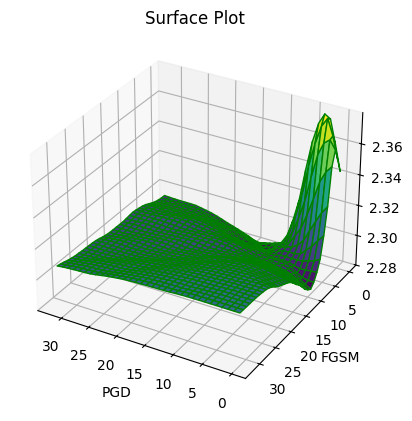

In [27]:
z = np.array(z)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='green')
ax.set_xlabel("PGD")
ax.set_ylabel("FGSM")
ax.set_title('Surface Plot')
ax.view_init(elev=30, azim=-240)
plt.show()

In [44]:
fgsm4scratch

(array([[ 0.,  0.,  0., ...,  0.,  0.,  0.],
        [ 1.,  1.,  1., ...,  1.,  1.,  1.],
        [ 2.,  2.,  2., ...,  2.,  2.,  2.],
        ...,
        [30., 30., 30., ..., 30., 30., 30.],
        [31., 31., 31., ..., 31., 31., 31.],
        [32., 32., 32., ..., 32., 32., 32.]], shape=(33, 33)),
 array([[ 0.,  1.,  2., ..., 30., 31., 32.],
        [ 0.,  1.,  2., ..., 30., 31., 32.],
        [ 0.,  1.,  2., ..., 30., 31., 32.],
        ...,
        [ 0.,  1.,  2., ..., 30., 31., 32.],
        [ 0.,  1.,  2., ..., 30., 31., 32.],
        [ 0.,  1.,  2., ..., 30., 31., 32.]], shape=(33, 33)),
 array([[2.33329034, 2.38067985, 2.40422773, ..., 2.2600472 , 2.25987768,
         2.25981879],
        [2.36709309, 2.40111208, 2.41384482, ..., 2.25995922, 2.25982547,
         2.25981879],
        [2.39287567, 2.41721392, 2.41826916, ..., 2.25989437, 2.25981569,
         2.25981879],
        ...,
        [2.25322604, 2.2499311 , 2.24752998, ..., 2.2555964 , 2.25660777,
         2.25728226],
 

In [ ]:
def loss_landscape(model, X, Y, direction, num_steps=32):
    num_steps += 1
    requires_grad_list = []
    for p in model.parameters(): 
        requires_grad_list.append(p.requires_grad)
        p.requires_grad_(False)
    loss = nn.CrossEntropyLoss()
    x_coord = np.outer(np.arange(0, num_steps, 1), np.ones(num_steps))
    y_coord = x_coord.T
    z_coord = np.array([np.zeros(num_steps) for i in range(num_steps)])
    model.eval()
    rand_dir = torch.randn_like(direction)
    rand_dir = rand_dir * torch.norm(direction) / torch.norm(rand_dir) 
    # direction = direction / torch.norm(direction)
    rand_dir -= direction * torch.sum(direction * rand_dir)
    rand_dir = rand_dir / torch.norm(rand_dir)
    print(direction)
    with torch.no_grad():
        for xstep in range(num_steps):
            for ystep in range(num_steps):
                newX = X + xstep * direction + ystep * rand_dir
                newX = torch.clamp(newX, 0, 1)
                adv_loss = loss(model(newX), Y)
                z_coord[xstep][ystep] = adv_loss.item()

    for p, b in zip(model.parameters(), requires_grad_list): 
        p.grad = None
        p.requires_grad_(b)

    X.requires_grad_(False)

    return x_coord, y_coord, z_coord
    

In [196]:
device = torch.device('mps')
pre_model_seq.to(device)
X = image.to(device)
Y = label.to(device)
X_adv = torch.clamp(pgd(pre_model_seq, X, Y), 0.0, 1.0).requires_grad_(False)
direction = X_adv[0] - X[0]
x, y, z = loss_landscape(pre_model_seq, X[0].unsqueeze(0), Y[0].unsqueeze(0), direction)

torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
torch.Size([10]) torch.Size([10, 10])
tensor([[[-3.1373e-02,  3.1373e-02,  3.1373e-02,  ...,  2.3529e-02,
           2.3529e-02,  0.0000e+00],
         [-3.1373e-02,  3.1373e-02,  3.1373e-02,  ..., -1.5686e-02,
           1.5686e-02,  1.5686e-02],
         [-3.1373e-02,  3.1373e-02,  3.1373e-02,  ...,  0.0000e+00,
           0.0000e+00,  2.9802e-08],
         ...,
         [ 3.1373e-02,  3.1373e-02,  3.1373e-02,  ...,  3.1373e-02,
           0.0000e+00,  3.1373e-02],
         [ 3.1373e-02,  3.1373e-02,  3.1373e-02,  ...,  0.0000e+00,
           3.1373e-02,  3.1373e-02],
         [ 3.1373e-02,  3.1373e-02, -1.5686e-02,  ...,  1.5686e-02,
           3.

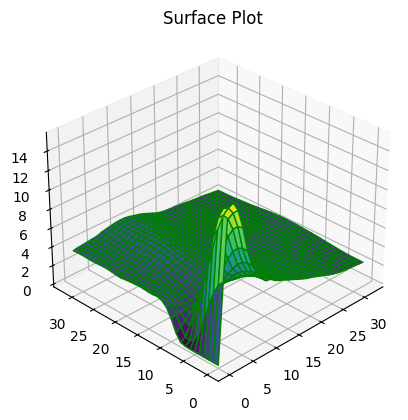

In [197]:
z = np.array(z)

fig = plt.figure()
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='viridis', edgecolor='green')
ax.set_title('Surface Plot')
ax.view_init(elev=30, azim=-135)
plt.show()